In [1]:
%load_ext autoreload
%autoreload 2
from functions import datasets, processing, method

In [2]:
data_dict = datasets.load_selected_data(num_datasets='all', num_neurons_per_dataset='all')
flat_data = datasets.flatten_datasets(data_dict)

In [3]:
# Create the subgroup
data_active_neurons = [flat_data for flat_data in flat_data if len(flat_data['spikes']) > 100]

# Quick check to see how many made the cut
print(f"Total flat_data: {len(flat_data)}")
print(f"flat_data with > 100 spikes: {len(data_active_neurons)}")

Total flat_data: 1157
flat_data with > 100 spikes: 502


In [4]:
#from functions.processing import upsample_v2
import numpy as np

# Define new sampling rate (e.g., 30Hz or 100Hz)
new_rate = 100 

upsampled_results = []

for neuron in data_active_neurons:
    # key lookup depends on your dictionary structure, assuming 'times', 'dff', 'spikes'
    times = neuron['t']
    dff = neuron['dff']
    spikes = neuron['spikes']
    
    # helper function usage
    upsampled_signal, upsampled_spikes, evenly_spaced_time = processing.upsample_v2(
        times=times, 
        dff=dff, 
        spikes=spikes, 
        new_rate=new_rate, 
        do_plot=False
    )
    
    upsampled_results.append({
        'original_neuron': neuron, # Keep reference if needed
        'upsampled_signal': upsampled_signal,
        'upsampled_spikes': upsampled_spikes,
        'evenly_spaced_time': evenly_spaced_time
    })

# If you specifically need just a simple list of the signals array:
list_of_upsampled_signals = [res['upsampled_signal'] for res in upsampled_results]

print(f"Upsampled {len(upsampled_results)} neurons.")

Upsampled 502 neurons.


In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_neuron_comparison(index, original_data_list, upsampled_data_list):
    """
    Plots the original vs upsampled signal and spikes for a given neuron index.
    
    Args:
        index (int): Index of the neuron to plot.
        original_data_list (list): List of original neuron dictionaries.
        upsampled_data_list (list): List of results from the upsampling step.
    """
    if index >= len(original_data_list) or index >= len(upsampled_data_list):
        print(f"Index {index} is out of bounds.")
        return

    # Extract original data
    orig_neuron = original_data_list[index]
    orig_times = orig_neuron['t']
    orig_dff = orig_neuron['dff']
    orig_spikes = orig_neuron['spikes']

    # Extract upsampled data
    ups_res = upsampled_data_list[index]
    ups_times = ups_res['evenly_spaced_time']
    ups_signal = ups_res['upsampled_signal']
    ups_spikes = ups_res['upsampled_spikes']

    plt.figure(figsize=(15, 6))

    # --- Plot Signals ---
    # Plot original signal as scatter/line to see points clearly
    plt.plot(orig_times, orig_dff, 'o-', color='gray', alpha=0.5, label='Original Signal', markersize=4)
    # Plot upsampled signal as a smooth line
    plt.plot(ups_times, ups_signal, '-', color='tab:blue', label='Upsampled Signal', linewidth=2)

    # --- Plot Spikes ---
    # We use vlines or tick marks to show spikes. 
    # To make them visible, we place them slightly above the max signal or superimpose.
    
    # Calculate a y-position for spikes so they are visible
    max_val = max(np.max(orig_dff), np.max(ups_signal))
    min_val = min(np.min(orig_dff), np.min(ups_signal))
    range_val = max_val - min_val
    
    # Offset spikes slightly
    spike_y_orig = max_val + range_val * 0.05
    spike_y_ups = max_val + range_val * 0.1
    
    # Plot Original Spikes
    plt.plot(orig_spikes, [spike_y_orig] * len(orig_spikes), '|', color='gray', 
             label='Original Spikes', markersize=15, markeredgewidth=2)
    
    # Plot Upsampled Spikes 
    # (Note: They should align closely with original spikes, maybe slightly shifted due to time grid if not exact)
    plt.plot(ups_spikes, [spike_y_ups] * len(ups_spikes), '|', color='tab:red', 
             label='Upsampled Spikes', markersize=15, markeredgewidth=2)

    plt.xlabel('Time (s)')
    plt.ylabel('Signal (DF/F)')
    plt.title(f'Neuron {index}: Original vs Upsampled Signal & Spikes')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

# Example usage:
# Change index to view different neurons

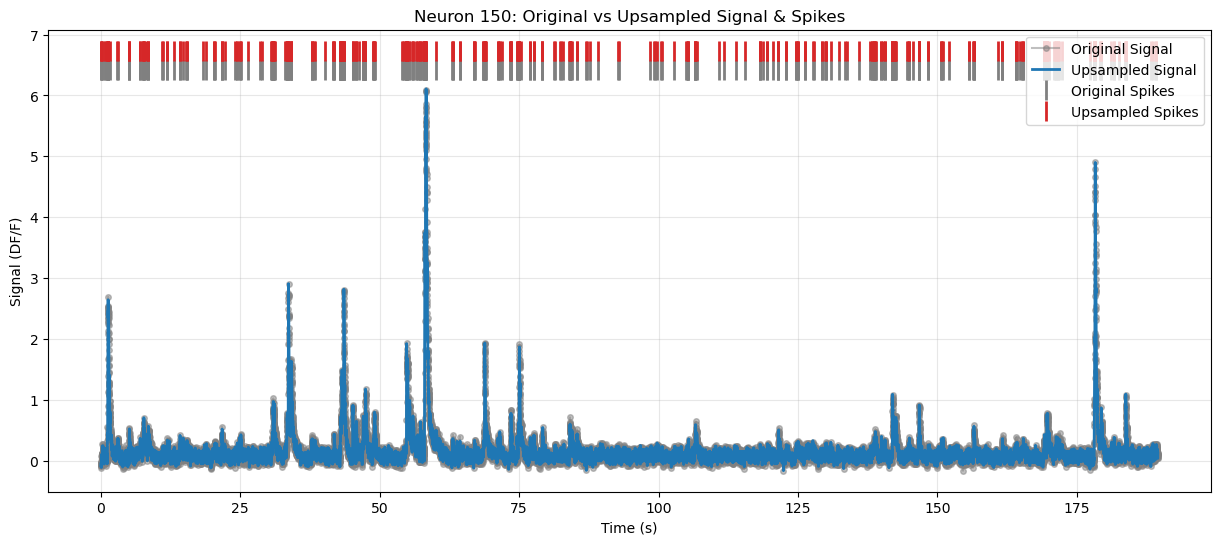

In [6]:
plot_neuron_comparison(150, data_active_neurons, upsampled_results)

In [7]:
from functions.method import estimate_tau
import numpy as np

# This will hold the final list of neuron dictionaries with tau added
neurons = []

for item in upsampled_results:
    # 1. Get references to data (using the keys from upsample_v2 results)
    u_sig = item['upsampled_signal']
    u_spk_times = item['upsampled_spikes'] # times in seconds
    u_time = item['evenly_spaced_time']
    
    # 2. Determine sampling rate (fs)
    if len(u_time) > 1:
        fs = 1.0 / (u_time[1] - u_time[0])
    else:
        fs = 30.0 # Default fallback
    
    t_start = u_time[0]

    # 3. Convert spike Times to Indices
    # Formula: index = (time - start_time) * fs
    u_spk_indices = ((u_spk_times - t_start) * fs).astype(int)
    
    # Filter indices to be within bounds
    u_spk_indices = u_spk_indices[(u_spk_indices >= 0) & (u_spk_indices < len(u_sig))]

    # 4. Estimate Tau
    try:
        # window_len=51, poly_order=3, cut_win=10 are standard defaults
        tau_val, fit_data = estimate_tau(u_sig, u_spk_indices, window_len=51, poly_order=3, cut_win=10)
    except Exception as e:
        print(f"Error for neuron: {e}")
        tau_val = np.nan
        fit_data = (None, None)

    # 5. Add new fields to the dictionary
    # We copy the item to avoid modifying the original list in place if that matters, 
    # or just modify 'item' directly. Here we modify 'item' and append to 'neurons'.
    item['tau'] = tau_val
    item['fit_data'] = fit_data
    
    # Add to our final list
    neurons.append(item)

print(f"Processed {len(neurons)} neurons. New fields 'tau' and 'fit_data' added.")

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
Processed 502 neurons. New fields 'tau' and 'fit_data' added.


In [8]:
from functions.method import get_spikes_train

# Assuming 'neurons' list has been populated
for neuron in neurons:
    # 1. Get required data
    u_spk = neuron['upsampled_spikes']      # Spike times in seconds
    u_time = neuron['evenly_spaced_time']   # Time grid
    
    # 2. Generate binary spike train
    spikes_train = get_spikes_train(u_spk, u_time)
    
    # 3. Add to neuron dictionary
    neuron['spikes_train'] = spikes_train

print(f"Added 'spikes_train' to {len(neurons)} neurons.")

Added 'spikes_train' to 502 neurons.


In [9]:
from functions.method import reconstruct_spikes

# Loop through neurons and add reconstructed spikes
for n in neurons:
    # 1. Get upsampled signal and tau
    u_sig = n['upsampled_signal']
    tau = n['tau']
    
    # 2. Check if tau is valid before reconstruction
    if not np.isnan(tau) and tau > 0:
        # Reconstruct spikes (returns 1D array since input is 1D)
        rec_spikes = reconstruct_spikes(u_sig, tau=tau)
        n['reconstructed_spikes'] = rec_spikes
    else:
        n['reconstructed_spikes'] = np.zeros_like(u_sig) # Or None

print("Added 'reconstructed_spikes' to neurons.")

Added 'reconstructed_spikes' to neurons.


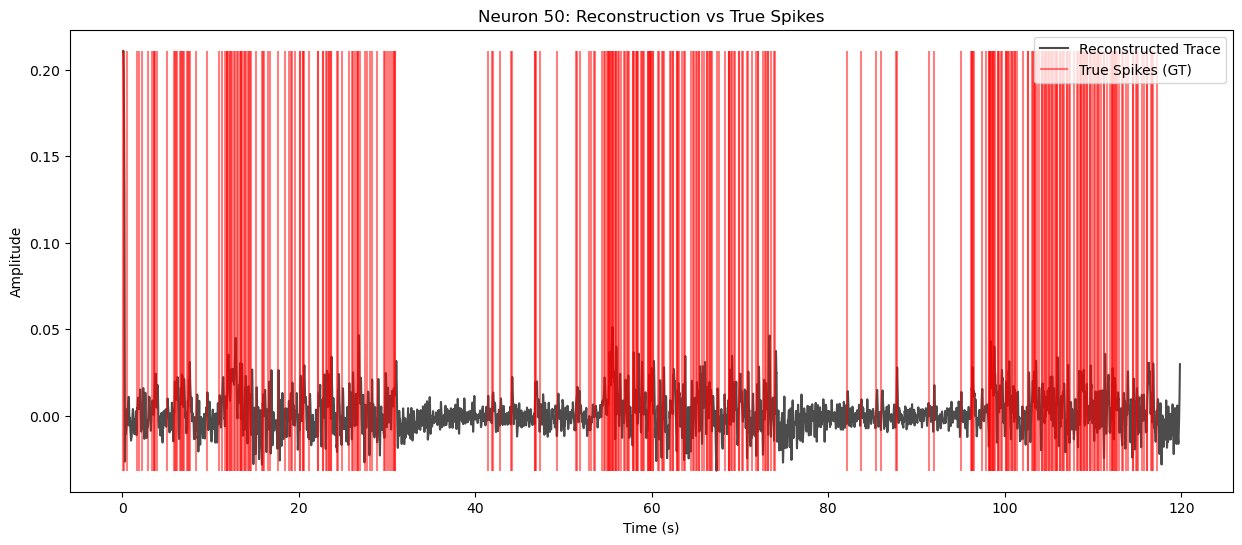

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Select a neuron by index (e.g., 10)
neuron_idx = 50
n = neurons[neuron_idx] # Accessing the dictionary for this neuron

# 2. Extract Data
# The continuous reconstruction is already stored in the list
rec_trace = n['reconstructed_spikes'] 
time_axis = n['evenly_spaced_time']     
true_spikes = n['original_neuron']['spikes'] # True spikes in SECONDS

# 3. Plot Comparison
plt.figure(figsize=(15, 6))

# Plot Reconstructed Spike Trace (Continuous)
plt.plot(time_axis, rec_trace, color='black', alpha=0.7, label='Reconstructed Trace')

# Plot True Spikes (Discrete Events)
# Use vertical lines at the exact timestamps
plt.vlines(true_spikes, 
           ymin=np.min(rec_trace), 
           ymax=np.max(rec_trace), 
           colors='red', 
           alpha=0.5, 
           label='True Spikes (GT)')

plt.title(f'Neuron {neuron_idx}: Reconstruction vs True Spikes')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In [11]:
import numpy as np
from functions.method import simulate_calcium_from_true_spikes, simulate_calcium_from_reconstructed_spikes

# Define sampling rate (assuming 100Hz from your upsampling step)
sampling_rate = 100 

for n in neurons:
    # 1. Retrieve Data
    true_spikes = n['original_neuron']['spikes'] # True spikes (seconds)
    rec_spikes = n.get('reconstructed_spikes')   # Reconstructed trace (continuous)
    time_grid = n['evenly_spaced_time']          # Time axis (seconds)
    tau = n.get('tau')                           # Tau (frames)
    
    # 2. Check Validity
    if rec_spikes is not None and not np.isnan(tau) and tau > 0:
        
        # --- Simulation A: From True Spikes ---
        sim_cal_true = simulate_calcium_from_true_spikes(
            true_spikes_sec=true_spikes,
            time_grid=time_grid,
            tau_frames=tau,
            sampling_rate=sampling_rate,
            noise_std=0.0 # Add noise if desired
        )
        n['sim_calcium_from_true'] = sim_cal_true
        
        # --- Simulation B: From Reconstructed Spikes ---
        sim_cal_rec = simulate_calcium_from_reconstructed_spikes(
            rec_spikes=rec_spikes,
            tau_frames=tau,
            noise_std=0.0
        )
        n['sim_calcium_from_rec'] = sim_cal_rec
        
    else:
        # Handle invalid cases
        zeros = np.zeros_like(n['upsampled_signal'])
        n['sim_calcium_from_true'] = zeros
        n['sim_calcium_from_rec'] = zeros

print("Added 'sim_calcium_from_true' and 'sim_calcium_from_rec' to neurons.")

Added 'sim_calcium_from_true' and 'sim_calcium_from_rec' to neurons.


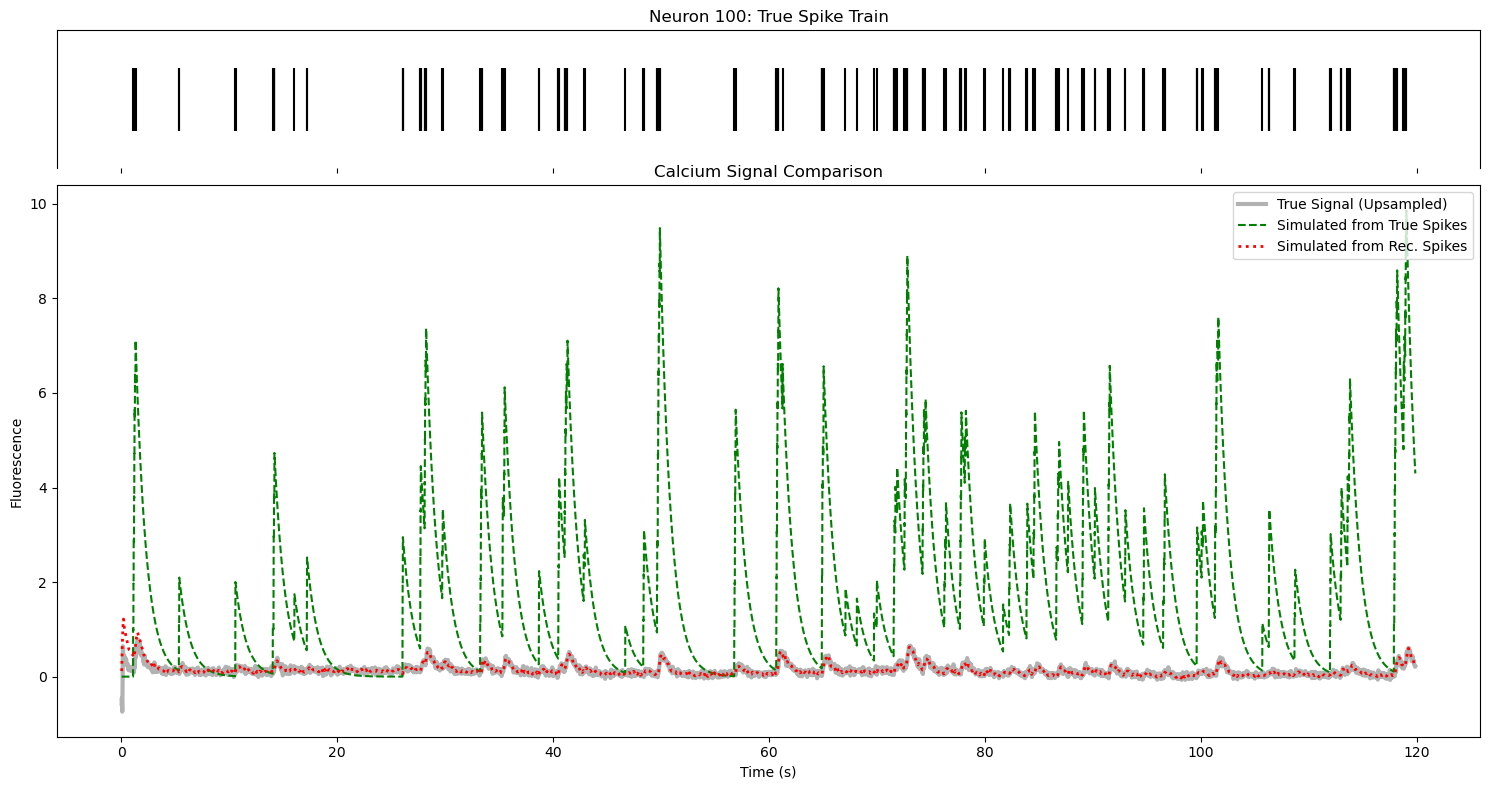

In [12]:
import matplotlib.pyplot as plt

def plot_neuron_calcium_comparison(neuron_idx, neurons_list):
    n = neurons_list[neuron_idx]
    
    # Extract Data
    time = n['evenly_spaced_time']
    true_signal = n['upsampled_signal']
    true_spikes = n['original_neuron']['spikes']
    
    sim_true = n.get('sim_calcium_from_true')
    sim_rec = n.get('sim_calcium_from_rec')
    
    # Create Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, 
                                   gridspec_kw={'height_ratios': [1, 4]})
    
    # --- Top Panel: Event Plot of True Spikes ---
    # We convert spike times to indices for eventplot if needed, or just plot on time axis
    ax1.eventplot(true_spikes, lineoffsets=0.5, linelengths=0.8, color='k')
    ax1.set_title(f'Neuron {neuron_idx}: True Spike Train')
    ax1.set_yticks([])
    ax1.spines['bottom'].set_visible(False) # Cosmetic: hide bottom spine to link plots
    
    # --- Bottom Panel: Calcium Signals Superimposed ---
    ax2.plot(time, true_signal, 'k-', alpha=0.3, lw=3, label='True Signal (Upsampled)')
    
    if sim_true is not None:
        ax2.plot(time, sim_true, 'g--', lw=1.5, label='Simulated from True Spikes')
        
    if sim_rec is not None:
        ax2.plot(time, sim_rec, 'r:', lw=2, label='Simulated from Rec. Spikes')
        
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Fluorescence')
    ax2.legend(loc='upper right')
    ax2.set_title('Calcium Signal Comparison')
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.05) # Bring plots closer
    plt.show()

# Example Usage:
plot_neuron_calcium_comparison(neuron_idx=100, neurons_list=neurons)

In [13]:
import matplotlib.pyplot as plt

def plot_separate_calcium_comparisons(neuron_idx, neurons_list):
    n = neurons_list[neuron_idx]
    
    # Extract Data
    time = n['evenly_spaced_time']
    true_signal = n['upsampled_signal']
    true_spikes = n['original_neuron']['spikes']
    
    sim_true = n.get('sim_calcium_from_true')
    sim_rec = n.get('sim_calcium_from_rec')
    
    # --- PLOT 1: True Signal vs. Simulated from TRUE Spikes ---
    fig1, (ax1a, ax1b) = plt.subplots(2, 1, figsize=(15, 6), sharex=True, 
                                      gridspec_kw={'height_ratios': [1, 4]})
    
    # Event Plot
    ax1a.eventplot(true_spikes, lineoffsets=0.5, linelengths=0.8, color='k')
    ax1a.set_title(f'Neuron {neuron_idx}: True Spikes & Simulation from TRUE Spikes')
    ax1a.set_yticks([])
    ax1a.spines['bottom'].set_visible(False)
    
    # Signal Plot
    ax1b.plot(time, true_signal, 'k-', alpha=0.3, lw=3, label='True Signal')
    if sim_true is not None:
        ax1b.plot(time, sim_true, 'g--', lw=1.5, label='Simulated (True Spikes)')
    
    ax1b.set_ylabel('Fluorescence')
    ax1b.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    # --- PLOT 2: True Signal vs. Simulated from RECONSTRUCTED Spikes ---
    fig2, (ax2a, ax2b) = plt.subplots(2, 1, figsize=(15, 6), sharex=True, 
                                      gridspec_kw={'height_ratios': [1, 4]})
    
    # Event Plot (Same true spikes for reference)
    ax2a.eventplot(true_spikes, lineoffsets=0.5, linelengths=0.8, color='k')
    ax2a.set_title(f'Neuron {neuron_idx}: True Spikes & Simulation from RECONSTRUCTED Spikes')
    ax2a.set_yticks([])
    ax2a.spines['bottom'].set_visible(False)
    
    # Signal Plot
    ax2b.plot(time, true_signal, 'k-', alpha=0.3, lw=3, label='True Signal')
    if sim_rec is not None:
        ax2b.plot(time, sim_rec, 'r:', lw=2, label='Simulated (Rec. Spikes)')
        
    ax2b.set_xlabel('Time (s)')
    ax2b.set_ylabel('Fluorescence')
    ax2b.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

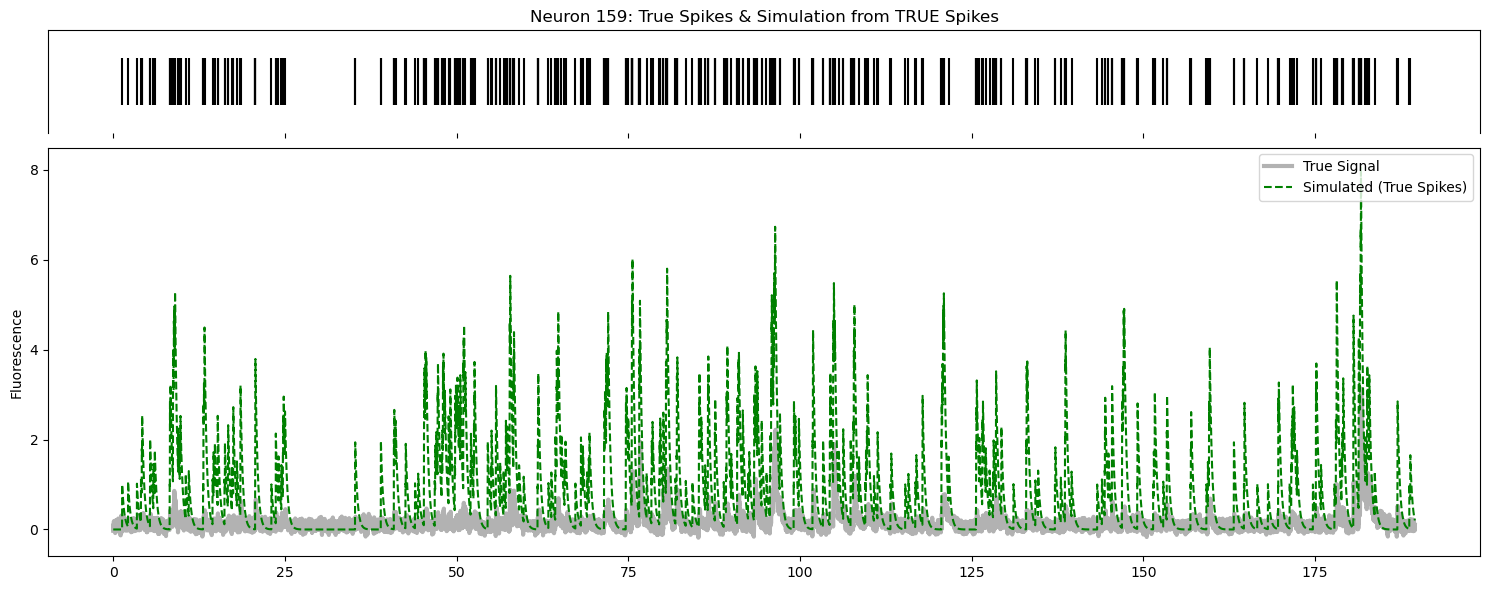

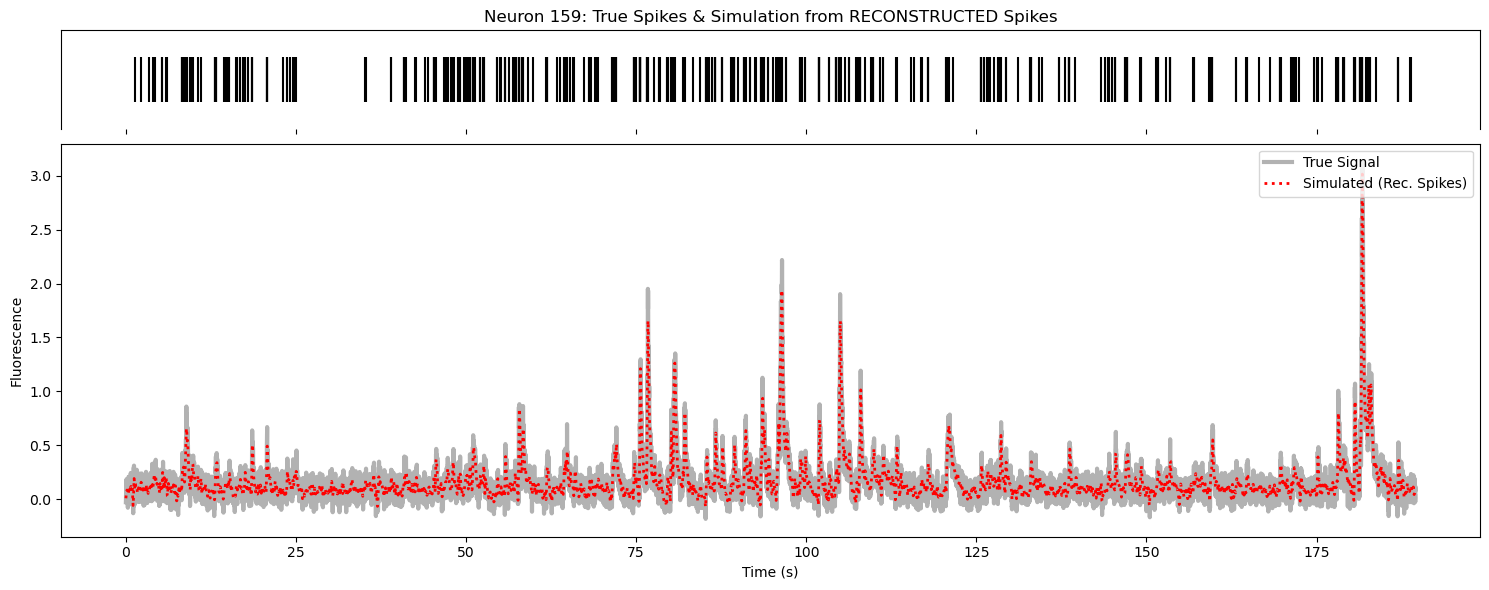

In [14]:
plot_separate_calcium_comparisons(neuron_idx=159, neurons_list=neurons)

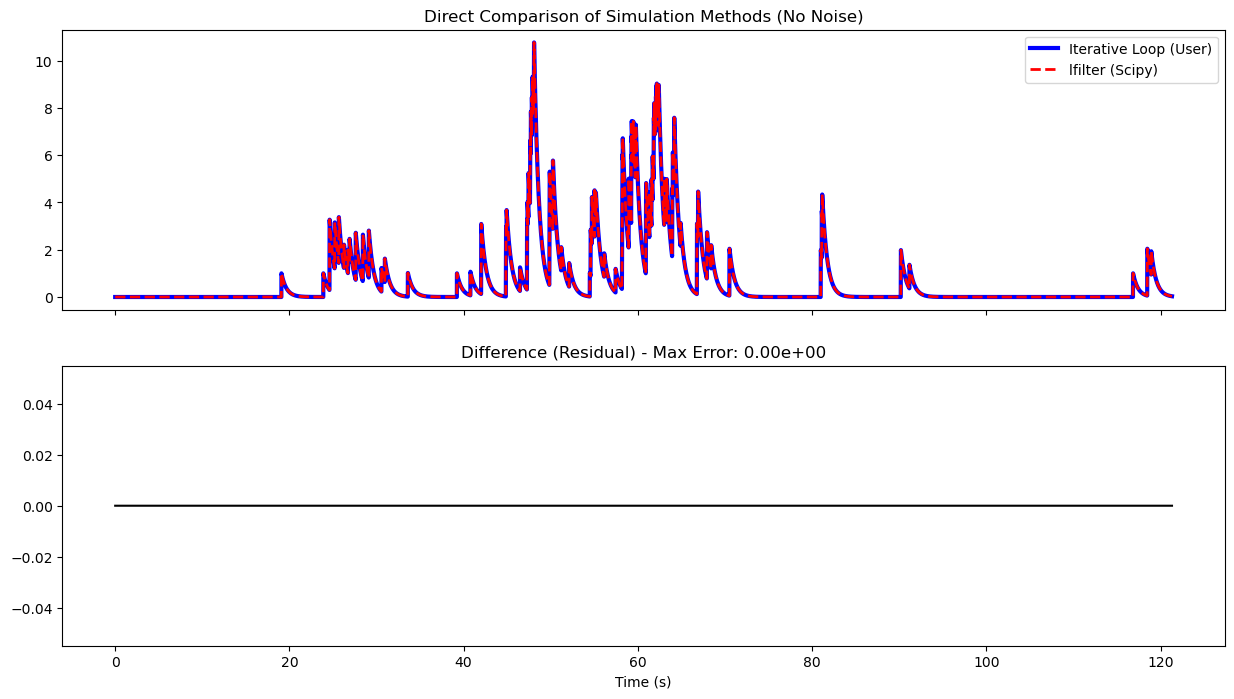

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from functions.method import simulate_calcium_iterative_true_spikes, simulate_calcium_from_true_spikes

# 1. Select Data
n = neurons[410]
true_spikes = n['original_neuron']['spikes']
time_grid = n['evenly_spaced_time']
tau = n['tau']
fs = 100

# 2. Run Both Simulations (Zero Noise for fair comparison of the core logic)
# A: Iterative (Your Logic)
sim_iter = simulate_calcium_iterative_true_spikes(
    true_spikes, time_grid, tau, fs, noise_intra=0.0, noise_rec=0.0
)

# B: Filter-based (Scipy lfilter)
sim_filter = simulate_calcium_from_true_spikes(
    true_spikes, time_grid, tau, fs, noise_std=0.0
)

# 3. Plot Difference
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(time_grid, sim_iter, 'b', lw=3, label='Iterative Loop (User)')
ax1.plot(time_grid, sim_filter, 'r--', lw=2, label='lfilter (Scipy)')
ax1.set_title('Direct Comparison of Simulation Methods (No Noise)')
ax1.legend()

# Show residual
residual = sim_iter - sim_filter
ax2.plot(time_grid, residual, 'k')
ax2.set_title(f'Difference (Residual) - Max Error: {np.max(np.abs(residual)):.2e}')
ax2.set_xlabel('Time (s)')

plt.show()

In [16]:
neurons[0]

{'original_neuron': {'global_id': 0,
  'dataset_name': 'DS01-OGB1-m-V1',
  'original_index': 0,
  'dff': array([ 0.01746  ,  0.005332 , -0.0038598, ...,  0.0057488,  0.024835 ,
         -0.0005397]),
  't': array([8.21355236e-02, 1.64271047e-01, 2.46406571e-01, ...,
         4.70143737e+02, 4.70225873e+02, 4.70308008e+02]),
  'spikes': array([1.5000e-02, 1.2058e+01, 1.3597e+01, 1.3781e+01, 1.3791e+01,
         1.5925e+01, 1.7483e+01, 1.7485e+01, 1.8478e+01, 1.8478e+01,
         1.8576e+01, 2.5017e+01, 2.5041e+01, 2.8315e+01, 2.9060e+01,
         2.9067e+01, 3.0130e+01, 3.0223e+01, 3.3823e+01, 3.7810e+01,
         3.7824e+01, 3.9209e+01, 4.1493e+01, 4.1965e+01, 4.2725e+01,
         4.3495e+01, 4.3894e+01, 4.3907e+01, 4.4317e+01, 4.4716e+01,
         4.6715e+01, 4.7132e+01, 4.7517e+01, 4.7953e+01, 5.0055e+01,
         5.0164e+01, 5.1836e+01, 5.2410e+01, 5.2443e+01, 5.8300e+01,
         5.8333e+01, 5.8496e+01, 5.8542e+01, 6.1582e+01, 6.1679e+01,
         6.3470e+01, 6.3476e+01, 7.1011e+01

In [17]:
neurons[0]['evenly_spaced_time'].shape

(47022,)

In [18]:
neurons[0]['original_neuron']['spikes'].shape

(359,)

In [19]:
neurons[0]['reconstructed_spikes'].shape

(47022,)

--- Calibration Dashboard for Neuron 470 ---


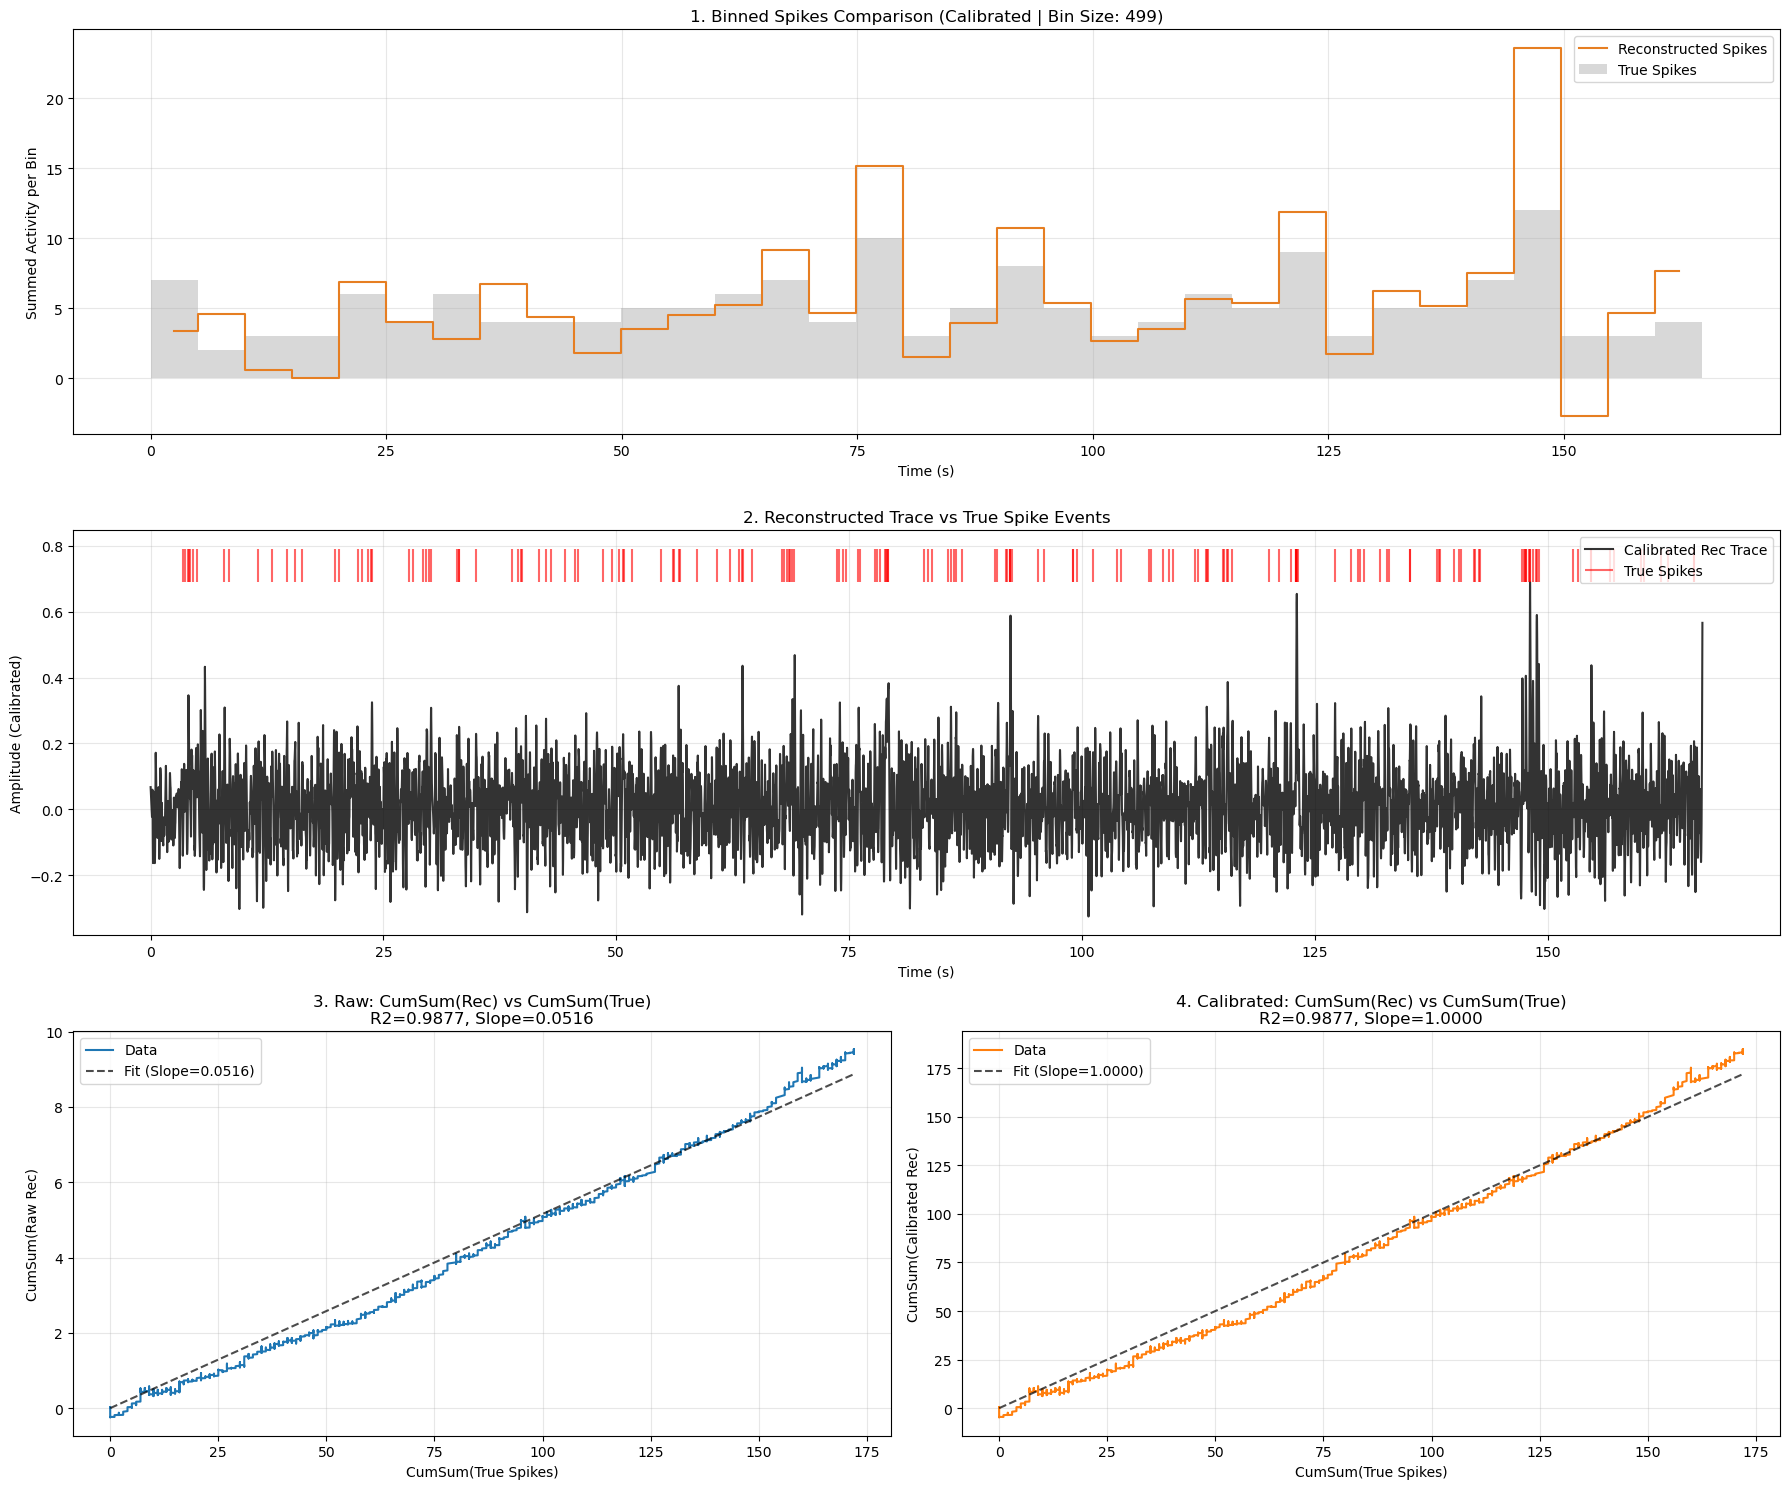

In [19]:
from functions.method import analyze_cumsum_calibration, plot_calibration_dashboard, get_spikes_train

# --- User Configuration ---
neuron_idx = 470
bin_size_sec = 5
# --------------------------

n = neurons[neuron_idx]

# 1. Prepare Data
time_vector = n['evenly_spaced_time']
if len(time_vector) > 1:
    dt = time_vector[1] - time_vector[0]
    fs = 1.0 / dt
else:
    fs = 100.0

reconstructed_spikes = n['reconstructed_spikes']
true_spike_times = n['original_neuron']['spikes']
true_spikes_train = get_spikes_train(true_spike_times, time_vector)

# 2. Analyze
# This now uses LinearRegression(fit_intercept=False) and r2_score internally
calibration_results = analyze_cumsum_calibration(true_spikes_train, reconstructed_spikes)

# 3. Plot Dashboard
bin_size_samples = int(bin_size_sec * fs)

print(f"--- Calibration Dashboard for Neuron {neuron_idx} ---")
plot_calibration_dashboard(
    true_spikes_train, 
    reconstructed_spikes, 
    calibration_results, 
    bin_size=bin_size_samples, 
    sampling_rate=fs
)

In [20]:
from functions.method import cumsum_slope

# Assuming 'neurons' list has 'spikes_train' and 'reconstructed_spikes' keys
for neuron in neurons:
    # 1. Get required data
    spk_train = neuron['spikes_train']
    rec_spk = neuron['reconstructed_spikes']
    
    # 2. Calculate slope
    slope = cumsum_slope(spk_train, rec_spk)
    
    # 3. Add to neuron dictionary
    neuron['cumsum_slope'] = slope

print(f"Added 'cumsum_slope' to {len(neurons)} neurons.")

Added 'cumsum_slope' to 502 neurons.


In [20]:
from functions.method import analyze_cumsum_calibration, get_spikes_train
import numpy as np

# Loop through all neurons
for i, n in enumerate(neurons):
    # 1. Prepare Data
    time_vector = n['evenly_spaced_time']
    reconstructed_spikes = n['reconstructed_spikes']
    true_spike_times = n['original_neuron']['spikes']
    
    # Generate binary spike train required for analysis
    true_spikes_train = get_spikes_train(true_spike_times, time_vector)
    
    # 2. Calculate Calibration Metrics
    # This returns slope/r2 for both raw and calibrated, we want RAW.
    calibration_results = analyze_cumsum_calibration(true_spikes_train, reconstructed_spikes)
    
    # 3. Add to neuron dictionary
    n['cumsum_r2_raw'] = calibration_results['r2_raw']
    n['cumsum_slope_raw'] = calibration_results['slope_raw']
    n['calibrated_spikes'] = calibration_results['calibrated_trace'] # Optionally save the trace too

    # Progress print
    if i % 10 == 0:
        print(f"Processed neuron {i}: R2={n['cumsum_r2_raw']:.3f}, Slope={n['cumsum_slope_raw']:.3f}")

print("Added 'cumsum_r2_raw' and 'cumsum_slope_raw' to all neurons.")

Processed neuron 0: R2=0.989, Slope=0.039
Processed neuron 10: R2=0.984, Slope=0.009
Processed neuron 20: R2=0.986, Slope=0.023
Processed neuron 30: R2=0.933, Slope=0.096
Processed neuron 40: R2=0.993, Slope=0.135
Processed neuron 50: R2=0.951, Slope=0.081
Processed neuron 60: R2=0.484, Slope=0.018
Processed neuron 70: R2=0.991, Slope=0.217
Processed neuron 80: R2=0.749, Slope=0.115
Processed neuron 90: R2=0.996, Slope=0.061
Processed neuron 100: R2=0.788, Slope=0.090
Processed neuron 110: R2=0.993, Slope=0.177
Processed neuron 120: R2=0.995, Slope=0.201
Processed neuron 130: R2=0.712, Slope=0.457
Processed neuron 140: R2=0.942, Slope=0.781
Processed neuron 150: R2=0.991, Slope=0.301
Processed neuron 160: R2=0.976, Slope=0.629
Processed neuron 170: R2=0.996, Slope=0.913
Processed neuron 180: R2=0.993, Slope=0.191
Processed neuron 190: R2=0.968, Slope=0.260
Processed neuron 200: R2=0.997, Slope=0.074
Processed neuron 210: R2=0.999, Slope=0.057
Processed neuron 220: R2=0.969, Slope=0.104

In [26]:
import pandas as pd
import numpy as np
from IPython.display import display

# 1. Extract data
data = []
for i, n in enumerate(neurons):
    db_name = n.get('dataset_name')
    if not db_name and 'original_neuron' in n:
        db_name = n['original_neuron'].get('dataset_name')
    if not db_name:
        db_name = 'Unknown'
        
    tau_val = n.get('tau', np.nan)
    slope_val = n.get('cumsum_slope_raw', np.nan)
    r2_val = n.get('cumsum_r2_raw', np.nan)
    
    data.append({
        'Neuron_ID': i,
        'Database': db_name,
        'Tau': tau_val,
        'Cumsum_Slope': slope_val,
        'R^2': r2_val
    })

df_results = pd.DataFrame(data)


In [28]:
# 1. (Keep your data extraction code as is)

# 2. Set the display limit for the dataframe itself
pd.set_option('display.max_rows', 50) 

# 3. Display with a scrollable container
print(f"Total Neurons: {len(df_results)}")

# This creates a scrollable window 400px high
display(df_results.style.set_table_attributes('style="display:inline-block; max-height:1000px; overflow-y:auto;"'))

Total Neurons: 502


,Neuron_ID,Database,Tau,Cumsum_Slope,R^2
0,0,DS01-OGB1-m-V1,205.300158,0.039456,0.988654
1,1,DS01-OGB1-m-V1,183.718850,0.039464,0.975320
2,2,DS01-OGB1-m-V1,1498.215544,0.001165,0.933665
3,3,DS01-OGB1-m-V1,179.348463,0.028632,0.998379
4,4,DS01-OGB1-m-V1,107.748766,0.049193,0.992792
5,5,DS01-OGB1-m-V1,143.159922,0.021846,0.986112
6,6,DS01-OGB1-m-V1,225.373844,0.033076,0.992227
7,7,DS01-OGB1-m-V1,183.036849,0.035953,0.263639
8,8,DS01-OGB1-m-V1,490.886998,0.021288,0.990151
9,9,DS01-OGB1-m-V1,398.162372,0.052004,0.978537


<Axes: >

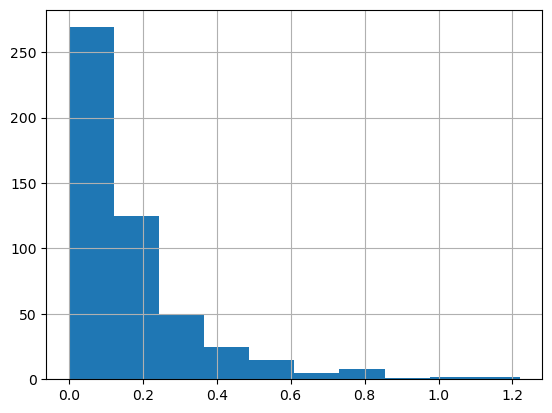

In [29]:
df_results['Cumsum_Slope'].hist()

<Axes: >

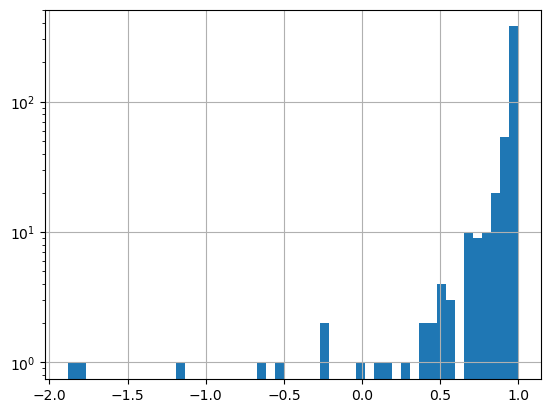

In [40]:
df_results['R^2'].hist(log=True, bins=50)

In [21]:
df_results.to_csv('tau_results.txt', sep=',', index=False)